# Deepfake Audio Detection using Dual-Stream CNN-GRU

This notebook implements an audio deepfake detection model using:
- **Feature Extraction**: Dual-Stream (Log-Mel Spectrograms + LFCCs) via torchaudio
- **Model Architecture**: Dual-Stream CNN + GRU with Late Fusion (DualFeature_CNN_GRU)
- **Primary Metric**: AUC-ROC
- **Label Mapping**: Fake = 0, Real = 1

**Dual-Stream Rationale:**
- **Mel-Spectrograms**: Capture low-frequency human phonetic structures
- **LFCCs**: Capture high-frequency synthetic vocoder artifacts

## 1. Setup and Imports

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings

import torch
import torch.nn as nn
import torch.optim as optim
import torchaudio
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    roc_curve,
    auc
)

# Suppress librosa and audio loading warnings
warnings.filterwarnings('ignore', category=UserWarning, module='librosa')
warnings.filterwarnings('ignore', category=FutureWarning, module='librosa')
warnings.filterwarnings('ignore', message='PySoundFile failed')
warnings.filterwarnings('ignore', message='audioread')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

Using device: cuda
GPU: NVIDIA RTX 4000 Ada Generation
GPU Memory: 19.99 GB


## 2. Dataset & Preprocessing

Import `AudioDataset` from the utils module.
This approach enables better multiprocessing support on Windows.

The AudioDataset class:
- Reads from `data/audio/` directory
- Processes waveforms to exactly 4.0 seconds (64,000 samples at 16kHz)
- Applies wrap-around padding for short clips
- **GPU-OPTIMIZED**: Returns raw waveforms (feature extraction moved to GPU model)
- Supports data augmentation with `is_train` parameter:
  - Gaussian White Noise injection (waveform level)
  
**Note**: Mel-Spectrogram, LFCC extraction, and SpecAugment are now performed on GPU in the model's forward pass for maximum performance.

In [2]:
# Import AudioDataset from utils module (enables multiprocessing on Windows)
import sys
sys.path.append('../utils')
from dataset import AudioDataset

## 3. Model Architecture: DualFeature_CNN_GRU

**GPU-Accelerated Dual-Stream with ResNet18 Backbones + Attention Fusion:**

This model performs all feature extraction on GPU for maximum performance:

1. **GPU Feature Extraction**: Converts raw waveform to Mel-Spectrogram and LFCC on GPU
2. **SpecAugment (Training Only)**: Applies frequency/time masking to Mel, time masking to LFCC
3. **Mel-Spectrogram Stream (ResNet18)**: Deep residual network with modified conv1 (1 channel input) and removed avgpool/fc layers
4. **LFCC Stream (ResNet18)**: Deep residual network with modified conv1 (1 channel input) and removed avgpool/fc layers
5. **Attention-Based Fusion**: Dynamic attention mechanism that learns optimal weighting of Mel and LFCC streams at each time step
6. **Bridge**: Adaptive pooling on frequency dimension, preserve time for temporal modeling
7. **GRU**: Bidirectional GRU with 2 layers for temporal modeling (input: 512 features)
8. **Classification Head**: Fully connected layers with dropout

In [3]:
class DualFeature_CNN_GRU(nn.Module):
    """
    Dual-Stream Audio Deepfake Detection Model using ResNet18 Backbones + Attention Fusion.

    This model processes two complementary audio features in parallel:
    1. Mel-Spectrogram Stream: Captures low-frequency human phonetic structures
    2. LFCC Stream: Captures high-frequency synthetic vocoder artifacts

    Architecture:
    - Two ResNet18 feature extractors (one for Mel, one for LFCC)
    - Attention-based fusion: Dynamically weighted combination of streams
    - Bidirectional GRU for temporal modeling
    - Classification head for binary deepfake detection

    Input: 
        - mel_x: Log-Mel Spectrogram (Batch, 1, 128, TimeFrames)
        - lfcc_x: LFCC features (Batch, 1, 128, TimeFrames)

    Output: 
        - Logits for binary classification (Batch, 2)
    """

    def __init__(self):
        super(DualFeature_CNN_GRU, self).__init__()

        # === MEL-SPECTROGRAM RESNET18 STREAM ===
        # Load ResNet18 with pre-trained ImageNet weights to reduce overfitting
        self.mel_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Adapt conv1 from 3 channels (RGB) to 1 channel (audio) by summing pre-trained weights
        # Clone the original pre-trained weights
        weight = self.mel_resnet.conv1.weight.clone()
        # Sum across the channel dimension to create 1-channel weights
        new_weight = weight.sum(dim=1, keepdim=True)
        # Create new 1-channel Conv2d layer (stride will be overwritten below)
        self.mel_resnet.conv1 = nn.Conv2d(
            1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        )
        # Assign the adapted pre-trained weights
        self.mel_resnet.conv1.weight = nn.Parameter(new_weight)
        
        # Remove avgpool and fc layers to preserve time dimension
        self.mel_resnet.avgpool = nn.Identity()
        self.mel_resnet.fc = nn.Identity()
        
        # === LFCC RESNET18 STREAM ===
        # Load ResNet18 with pre-trained ImageNet weights to reduce overfitting
        self.lfcc_resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Adapt conv1 from 3 channels (RGB) to 1 channel (audio) by summing pre-trained weights
        # Clone the original pre-trained weights
        weight = self.lfcc_resnet.conv1.weight.clone()
        # Sum across the channel dimension to create 1-channel weights
        new_weight = weight.sum(dim=1, keepdim=True)
        # Create new 1-channel Conv2d layer (stride will be overwritten below)
        self.lfcc_resnet.conv1 = nn.Conv2d(
            1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False
        )
        # Assign the adapted pre-trained weights
        self.lfcc_resnet.conv1.weight = nn.Parameter(new_weight)
        
        # Remove avgpool and fc layers to preserve time dimension
        self.lfcc_resnet.avgpool = nn.Identity()
        self.lfcc_resnet.fc = nn.Identity()
        
        # === FIX RESNET TEMPORAL DECIMATION ===
        # Modify stride patterns to preserve time dimension (only downsample frequency)
        # This prevents excessive temporal downsampling that would harm GRU input
        
        # Fix Mel ResNet
        self.mel_resnet.conv1.stride = (2, 1)  # Only downsample frequency
        self.mel_resnet.maxpool.stride = (2, 1)  # Only downsample frequency
        
        # Fix layer2, layer3, layer4 downsampling blocks
        for layer in [self.mel_resnet.layer2, self.mel_resnet.layer3, self.mel_resnet.layer4]:
            layer[0].conv1.stride = (2, 1)  # First block in each layer
            if layer[0].downsample is not None:
                layer[0].downsample[0].stride = (2, 1)
        
        # Fix LFCC ResNet
        self.lfcc_resnet.conv1.stride = (2, 1)  # Only downsample frequency
        self.lfcc_resnet.maxpool.stride = (2, 1)  # Only downsample frequency
        
        # Fix layer2, layer3, layer4 downsampling blocks
        for layer in [self.lfcc_resnet.layer2, self.lfcc_resnet.layer3, self.lfcc_resnet.layer4]:
            layer[0].conv1.stride = (2, 1)  # First block in each layer
            if layer[0].downsample is not None:
                layer[0].downsample[0].stride = (2, 1)
        
        # Adaptive pooling to reduce frequency dimension only
        self.mel_freq_pool = nn.AdaptiveAvgPool2d((1, None))  # Pool freq to 1, keep time
        self.lfcc_freq_pool = nn.AdaptiveAvgPool2d((1, None))  # Pool freq to 1, keep time
        
        # === ATTENTION-BASED FUSION ===
        # Attention mechanism to dynamically weight Mel and LFCC streams
        self.attention_fc = nn.Sequential(
            nn.Linear(512 * 2, 256),  # Process stacked features
            nn.Tanh(),
            nn.Linear(256, 2),  # Output 2 attention scores (for Mel and LFCC)
            nn.Softmax(dim=-1)  # Normalize to sum to 1
        )
        
        # === FUSION NORMALIZATION ===
        # Layer normalization to stabilize fused features before GRU
        self.fusion_norm = nn.LayerNorm(512)
        
        # === TEMPORAL DROPOUT ===
        # Dropout applied to fused features before GRU for stronger regularization
        self.temporal_dropout = nn.Dropout(0.2)
        
        # === GRU SEQUENCE MODELING ===
        # GRU takes 512-dimensional fused features
        self.gru = nn.GRU(
            input_size=512,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )
        
        # === CLASSIFICATION HEAD ===
        # Bidirectional GRU outputs 2 * hidden_size = 512
        self.classifier = nn.Sequential(
            nn.Linear(512, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    

    def forward(self, mel_x, lfcc_x):
        """
        Forward pass with dual-stream input and attention-based fusion.
        
        Args:
            mel_x: Log-Mel Spectrogram tensor of shape (Batch, 1, 128, TimeFrames)
            lfcc_x: LFCC tensor of shape (Batch, 1, 128, TimeFrames)
        
        Returns:
            Logits of shape (Batch, 2)
        """
        batch_size = mel_x.size(0)
        
        # === MEL-SPECTROGRAM RESNET18 STREAM ===
        # Pass through ResNet18 layers (conv1 -> bn1 -> relu -> maxpool -> layer1-4)
        mel_x = self.mel_resnet.conv1(mel_x)
        mel_x = self.mel_resnet.bn1(mel_x)
        mel_x = self.mel_resnet.relu(mel_x)
        mel_x = self.mel_resnet.maxpool(mel_x)
        mel_x = self.mel_resnet.layer1(mel_x)
        mel_x = self.mel_resnet.layer2(mel_x)
        mel_x = self.mel_resnet.layer3(mel_x)
        mel_x = self.mel_resnet.layer4(mel_x)  # Output: (Batch, 512, Freq', Time')
        
        # Pool frequency dimension only, preserve time
        mel_x = self.mel_freq_pool(mel_x)  # (Batch, 512, 1, Time')
        mel_x = mel_x.squeeze(2)  # (Batch, 512, Time')
        mel_x = mel_x.permute(0, 2, 1)  # (Batch, Time', 512)
        
        # === LFCC RESNET18 STREAM ===
        # Pass through ResNet18 layers (conv1 -> bn1 -> relu -> maxpool -> layer1-4)
        lfcc_x = self.lfcc_resnet.conv1(lfcc_x)
        lfcc_x = self.lfcc_resnet.bn1(lfcc_x)
        lfcc_x = self.lfcc_resnet.relu(lfcc_x)
        lfcc_x = self.lfcc_resnet.maxpool(lfcc_x)
        lfcc_x = self.lfcc_resnet.layer1(lfcc_x)
        lfcc_x = self.lfcc_resnet.layer2(lfcc_x)
        lfcc_x = self.lfcc_resnet.layer3(lfcc_x)
        lfcc_x = self.lfcc_resnet.layer4(lfcc_x)  # Output: (Batch, 512, Freq', Time')
        
        # Pool frequency dimension only, preserve time
        lfcc_x = self.lfcc_freq_pool(lfcc_x)  # (Batch, 512, 1, Time')
        lfcc_x = lfcc_x.squeeze(2)  # (Batch, 512, Time')
        lfcc_x = lfcc_x.permute(0, 2, 1)  # (Batch, Time', 512)
        
        # === ATTENTION-BASED FUSION ===
        # Stack features: (Batch, Time', 1024)
        stacked = torch.cat([mel_x, lfcc_x], dim=2)
        
        # Calculate attention weights for each time step
        # attention_weights: (Batch, Time', 2) where weights[:, :, 0] is for mel, [:, :, 1] is for lfcc
        attention_weights = self.attention_fc(stacked)  # (Batch, Time', 2)
        
        # Apply attention weights
        # Expand dimensions: (Batch, Time', 2, 1)
        attention_weights = attention_weights.unsqueeze(-1)
        
        # Stack mel and lfcc: (Batch, Time', 2, 512)
        dual_features = torch.stack([mel_x, lfcc_x], dim=2)
        
        # Weighted sum: (Batch, Time', 512)
        fused_features = (dual_features * attention_weights).sum(dim=2)
        
        # Apply layer normalization to stabilize fused features
        fused_features = self.fusion_norm(fused_features)
        
        # === GRU SEQUENCE MODELING ===
        gru_out, hidden = self.gru(fused_features)  # gru_out: (Batch, Time', 512)
        
        # Extract final hidden state from last time step
        # Concatenate forward and backward hidden states from the last layer
        final_hidden = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)  # (Batch, 512)
        
        # === CLASSIFICATION ===
        logits = self.classifier(final_hidden)  # (Batch, 2)
        
        return logits

## 4. Training and Validation Functions

In [4]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):

    """

    Train the model for one epoch with dual-stream input.

    

    Returns:

        tuple: (avg_loss, accuracy)

    """

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0

    

    progress_bar = tqdm(dataloader, desc='Training', leave=False)

    

    # UPDATED: Unpack three items from dataloader (mels, lfccs, labels)

    for mels, lfccs, labels in progress_bar:

        mels = mels.to(device)

        lfccs = lfccs.to(device)

        labels = labels.to(device)

        

        # Zero gradients

        optimizer.zero_grad()

        

        # UPDATED: Forward pass with dual inputs

        logits = model(mels, lfccs)

        loss = criterion(logits, labels)

        

        # Backward pass

        loss.backward()

        # Gradient clipping for training stability

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        

        # Calculate accuracy

        _, predicted = torch.max(logits, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        

        running_loss += loss.item()

        current_acc = 100.0 * correct / total

        progress_bar.set_postfix({'loss': loss.item(), 'acc': f'{current_acc:.2f}%'})

    

    avg_loss = running_loss / len(dataloader)

    accuracy = 100.0 * correct / total

    return avg_loss, accuracy





def validate(model, dataloader, criterion, device):

    """

    Validate the model with dual-stream input.

    

    Returns:

        Dictionary containing:

        - val_loss: Average validation loss

        - accuracy: Classification accuracy

        - pr_auc: PR-AUC (treating Fake as positive class)

        - roc_auc: ROC-AUC (treating Fake as positive class)

        - all_labels: Ground truth labels

        - all_probs: Predicted probabilities for Fake class

    """

    model.eval()

    running_loss = 0.0

    

    all_labels = []

    all_probs = []

    all_preds = []

    

    progress_bar = tqdm(dataloader, desc='Validating', leave=False)

    

    with torch.no_grad():

        # UPDATED: Unpack three items from dataloader (mels, lfccs, labels)

        for mels, lfccs, labels in progress_bar:

            mels = mels.to(device)

            lfccs = lfccs.to(device)

            labels = labels.to(device)

            

            # UPDATED: Forward pass with dual inputs

            logits = model(mels, lfccs)

            loss = criterion(logits, labels)

            

            running_loss += loss.item()

            

            # Get probabilities (softmax)

            probs = torch.softmax(logits, dim=1)

            

            # Extract probability of Fake (Class 0)

            fake_probs = probs[:, 0].cpu().numpy()

            

            # Get predictions

            preds = torch.argmax(logits, dim=1).cpu().numpy()

            

            all_labels.extend(labels.cpu().numpy())

            all_probs.extend(fake_probs)

            all_preds.extend(preds)

    

    avg_loss = running_loss / len(dataloader)

    

    # Calculate metrics

    accuracy = accuracy_score(all_labels, all_preds)

    
    # Convert labels to treat Fake (0) as positive class
    labels_fake_positive = (np.array(all_labels) == 0).astype(int)

    # PR-AUC: Treating Fake as positive class (fake probs already extracted)
    pr_auc = average_precision_score(labels_fake_positive, all_probs)

    # ROC-AUC: Treating Fake as positive class (fake probs already extracted)
    roc_auc = roc_auc_score(labels_fake_positive, all_probs)

    

    return {

        'val_loss': avg_loss,

        'accuracy': accuracy,

        'pr_auc': pr_auc,

        'roc_auc': roc_auc,

        'all_labels': all_labels,

        'all_probs': all_probs

    }

## 5. Data Loading

Create DataLoaders for train, validation, and test sets.

**Data Augmentation**: The training dataset uses augmentation (`is_train=True`) to improve model generalization:
- **Gaussian White Noise Injection** (waveform level): Random SNR between 0.001 and 0.01
- **SpecAugment** (GPU, in model's forward pass): Frequency masking (15 bins) and time masking (35 frames)

Validation and test datasets use `is_train=False` for clean evaluation.

**Note**: Feature extraction now happens on GPU in the model, so the dataloader only provides raw waveforms.

In [5]:
# Define paths to processed data

train_dir = '../data/audio/train'

val_dir = '../data/audio/val'

test_dir = '../data/audio/test'



# Create datasets

print("Creating datasets...")

# Training dataset with augmentation enabled

train_dataset = AudioDataset(train_dir, target_sr=16000, target_duration=4.0, is_train=True)

# Validation and test datasets without augmentation

val_dataset = AudioDataset(val_dir, target_sr=16000, target_duration=4.0, is_train=False)

test_dataset = AudioDataset(test_dir, target_sr=16000, target_duration=4.0, is_train=False)



# Create dataloaders

batch_size = 32

# On Windows, soundfile has issues with multiprocessing

# Use num_workers=0 for stability (single-process data loading)

num_workers = 0  # Set to 0 if you encounter freezing issues



train_loader = DataLoader(

    train_dataset,

    batch_size=batch_size,

    shuffle=True,

    num_workers=num_workers,

    pin_memory=True if torch.cuda.is_available() else False,

    persistent_workers=True if num_workers > 0 else False

)



val_loader = DataLoader(

    val_dataset,

    batch_size=batch_size,

    shuffle=False,

    num_workers=num_workers,

    pin_memory=True if torch.cuda.is_available() else False,

    persistent_workers=True if num_workers > 0 else False

)



test_loader = DataLoader(

    test_dataset,

    batch_size=batch_size,

    shuffle=False,

    num_workers=num_workers,

    pin_memory=True if torch.cuda.is_available() else False,

    persistent_workers=True if num_workers > 0 else False

)



print(f"\nDataLoaders created:")

print(f"  Train batches: {len(train_loader)}")

print(f"  Val batches: {len(val_loader)}")

print(f"  Test batches: {len(test_loader)}")

Creating datasets...
Loaded 7700 audio files from ../data/audio/train
  Fake (Class 0): 3850
  Real (Class 1): 3850
Loaded 1650 audio files from ../data/audio/val
  Fake (Class 0): 825
  Real (Class 1): 825
Loaded 1650 audio files from ../data/audio/test
  Fake (Class 0): 825
  Real (Class 1): 825

DataLoaders created:
  Train batches: 241
  Val batches: 52
  Test batches: 52


## 6. Model Initialization

In [6]:
# Initialize model with Dual-Stream architecture

model = DualFeature_CNN_GRU().to(device)



# Count parameters

total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)



print(f"Model initialized:")

print(f"  Total parameters: {total_params:,}")

print(f"  Trainable parameters: {trainable_params:,}")



# Define loss function and optimizer

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)



# REGULARIZATION: Add weight_decay for L2 regularization to prevent overfitting

# STABILIZATION: Reduced learning rate from 1e-4 to 5e-5 for more stable training

optimizer = optim.Adam(model.parameters(), lr=5e-5, weight_decay=1e-4)



# LEARNING RATE SCHEDULER: Reduce learning rate when validation loss plateaus

# This helps the model converge better and reduces overfitting

# STABILIZATION: Increased patience from 2 to 5 to tolerate noisy validation metrics

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(

    optimizer, 

    mode='min',          # Minimize validation loss

    factor=0.5,          # Reduce LR by half when triggered

    patience=5,          # Wait 5 epochs before reducing LR (increased for stability)

    verbose=True         # Print message when LR is reduced

)



print(f"\nOptimizer: Adam (lr=5e-5, weight_decay=1e-4)")

print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

print(f"Loss: CrossEntropyLoss")

Model initialized:
  Total parameters: 25,036,036
  Trainable parameters: 25,036,036

Optimizer: Adam (lr=5e-5, weight_decay=1e-4)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
Loss: CrossEntropyLoss


c:\Users\wcliang3\Desktop\Git_repo\CS4487-AIGC-Detection-Group20\CS4487-AIGC-Detection-Group20\.venv\Lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


## 7. Training Loop

Train for 50 epochs and save the model with the highest Validation ROC-AUC.

In [7]:
# Training configuration

NUM_EPOCHS = 30

EARLY_STOP_PATIENCE = 5

MODEL_SAVE_PATH = '../saved_models/best_audio_cnn_gru.pth'



best_val_auc = 0.0

best_epoch = 0

epochs_no_improve = 0



# Create directory if it doesn't exist

os.makedirs('../saved_models', exist_ok=True)



# History tracking

history = {

    'train_loss': [],

    'train_acc': [],

    'val_loss': [],

    'val_accuracy': [],

    'val_pr_auc': [],

    'val_roc_auc': [],

    'learning_rate': []  # Track learning rate changes

}



print(f"Starting training for {NUM_EPOCHS} epochs...")

print(f"Configuration:")

print(f"  - Model: AudioCNN_GRU")

print(f"  - Batch Size: {batch_size}")

print(f"  - Learning Rate: 5e-5 (with ReduceLROnPlateau scheduler)")

print(f"  - Weight Decay: 1e-4 (L2 Regularization)")

print(f"  - Optimizer: Adam")

print(f"  - Loss: CrossEntropyLoss")

print(f"  - Early Stopping Patience: {EARLY_STOP_PATIENCE}")

print(f"  - Scheduler Patience: 5 (relaxed for stability)")

print(f"  - Primary Metric: AUC-ROC (higher is better)")

print(f"  - Model Save Path: {MODEL_SAVE_PATH}\n")



# Create epoch progress bar

epoch_pbar = tqdm(range(NUM_EPOCHS), desc='Overall Progress', position=0)



for epoch in epoch_pbar:

    # Training

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    

    # Validation

    val_metrics = validate(model, val_loader, criterion, device)

    

    # Get current learning rate

    current_lr = optimizer.param_groups[0]['lr']

    

    # Update history

    history['train_loss'].append(train_loss)

    history['train_acc'].append(train_acc)

    history['val_loss'].append(val_metrics['val_loss'])

    history['val_accuracy'].append(val_metrics['accuracy'])

    history['val_pr_auc'].append(val_metrics['pr_auc'])

    history['val_roc_auc'].append(val_metrics['roc_auc'])

    history['learning_rate'].append(current_lr)

    

    # SCHEDULER STEP: Reduce learning rate if validation loss plateaus

    scheduler.step(val_metrics['val_loss'])

    

    # Update epoch progress bar with metrics

    epoch_pbar.set_postfix({

        'Train Loss': f'{train_loss:.4f}',

        'Train Acc': f'{train_acc:.2f}%',

        'Val AUC': f'{val_metrics["roc_auc"]:.4f}',

        'Best AUC': f'{best_val_auc:.4f}'

    })

    

    # Print detailed metrics

    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")

    print("-" * 70)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")

    print(f"Val Loss: {val_metrics['val_loss']:.4f} | Val Acc: {val_metrics['accuracy']*100:.2f}%")

    print(f"Val AUC-ROC: {val_metrics['roc_auc']:.4f} | Val PR-AUC: {val_metrics['pr_auc']:.4f}")

    print(f"Learning Rate: {current_lr:.6f}")  # Track LR changes for debugging

    

    # Save best model based on AUC-ROC and check early stopping

    if val_metrics['roc_auc'] > best_val_auc:

        best_val_auc = val_metrics['roc_auc']

        best_epoch = epoch

        epochs_no_improve = 0

        

        torch.save({

            'epoch': epoch,

            'model_state_dict': model.state_dict(),

            'optimizer_state_dict': optimizer.state_dict(),

            'val_loss': val_metrics['val_loss'],

            'val_acc': val_metrics['accuracy'],

            'val_auc': val_metrics['roc_auc'],

            'val_pr_auc': val_metrics['pr_auc'],

        }, MODEL_SAVE_PATH)

        

        print(f"✓ New best model saved! (Val AUC-ROC: {best_val_auc:.4f})")

    else:

        epochs_no_improve += 1

        print(f"No improvement in AUC-ROC for {epochs_no_improve} epoch(s)")

    

    if epochs_no_improve >= EARLY_STOP_PATIENCE:

        print(f'\nEarly stopping triggered after {epoch+1} epochs!')

        break



print("\n" + "=" * 70)

print("Training completed!")

print(f"Best model at epoch {best_epoch+1} with Val AUC-ROC: {best_val_auc:.4f}")

print("=" * 70)

Starting training for 30 epochs...
Configuration:
  - Model: AudioCNN_GRU
  - Batch Size: 32
  - Learning Rate: 5e-5 (with ReduceLROnPlateau scheduler)
  - Weight Decay: 1e-4 (L2 Regularization)
  - Optimizer: Adam
  - Loss: CrossEntropyLoss
  - Early Stopping Patience: 5
  - Scheduler Patience: 5 (relaxed for stability)
  - Primary Metric: AUC-ROC (higher is better)
  - Model Save Path: ../saved_models/best_audio_cnn_gru.pth



Overall Progress:   0%|          | 0/30 [00:00<?, ?it/s]

Training:   0%|          | 0/241 [00:00<?, ?it/s]

Validating:   0%|          | 0/52 [00:00<?, ?it/s]


Epoch 1/30
----------------------------------------------------------------------
Train Loss: 0.5926 | Train Acc: 73.84%
Val Loss: 0.5256 | Val Acc: 76.61%
Val AUC-ROC: 0.8549 | Val PR-AUC: 0.8383
Learning Rate: 0.000050
✓ New best model saved! (Val AUC-ROC: 0.8549)


...

Validating:   0%|          | 0/52 [00:00<?, ?it/s]


Epoch 14/30
----------------------------------------------------------------------
Train Loss: 0.2407 | Train Acc: 97.96%
Val Loss: 0.2824 | Val Acc: 95.15%
Val AUC-ROC: 0.9909 | Val PR-AUC: 0.9915
Learning Rate: 0.000050
No improvement in AUC-ROC for 4 epoch(s)


Training:   0%|          | 0/241 [00:00<?, ?it/s]

Validating:   0%|          | 0/52 [00:00<?, ?it/s]


Epoch 15/30
----------------------------------------------------------------------
Train Loss: 0.2449 | Train Acc: 97.71%
Val Loss: 0.2773 | Val Acc: 95.70%
Val AUC-ROC: 0.9913 | Val PR-AUC: 0.9927
Learning Rate: 0.000050
No improvement in AUC-ROC for 5 epoch(s)

Early stopping triggered after 15 epochs!

Training completed!
Best model at epoch 10 with Val AUC-ROC: 0.9934


## 8. Visualization: Training History

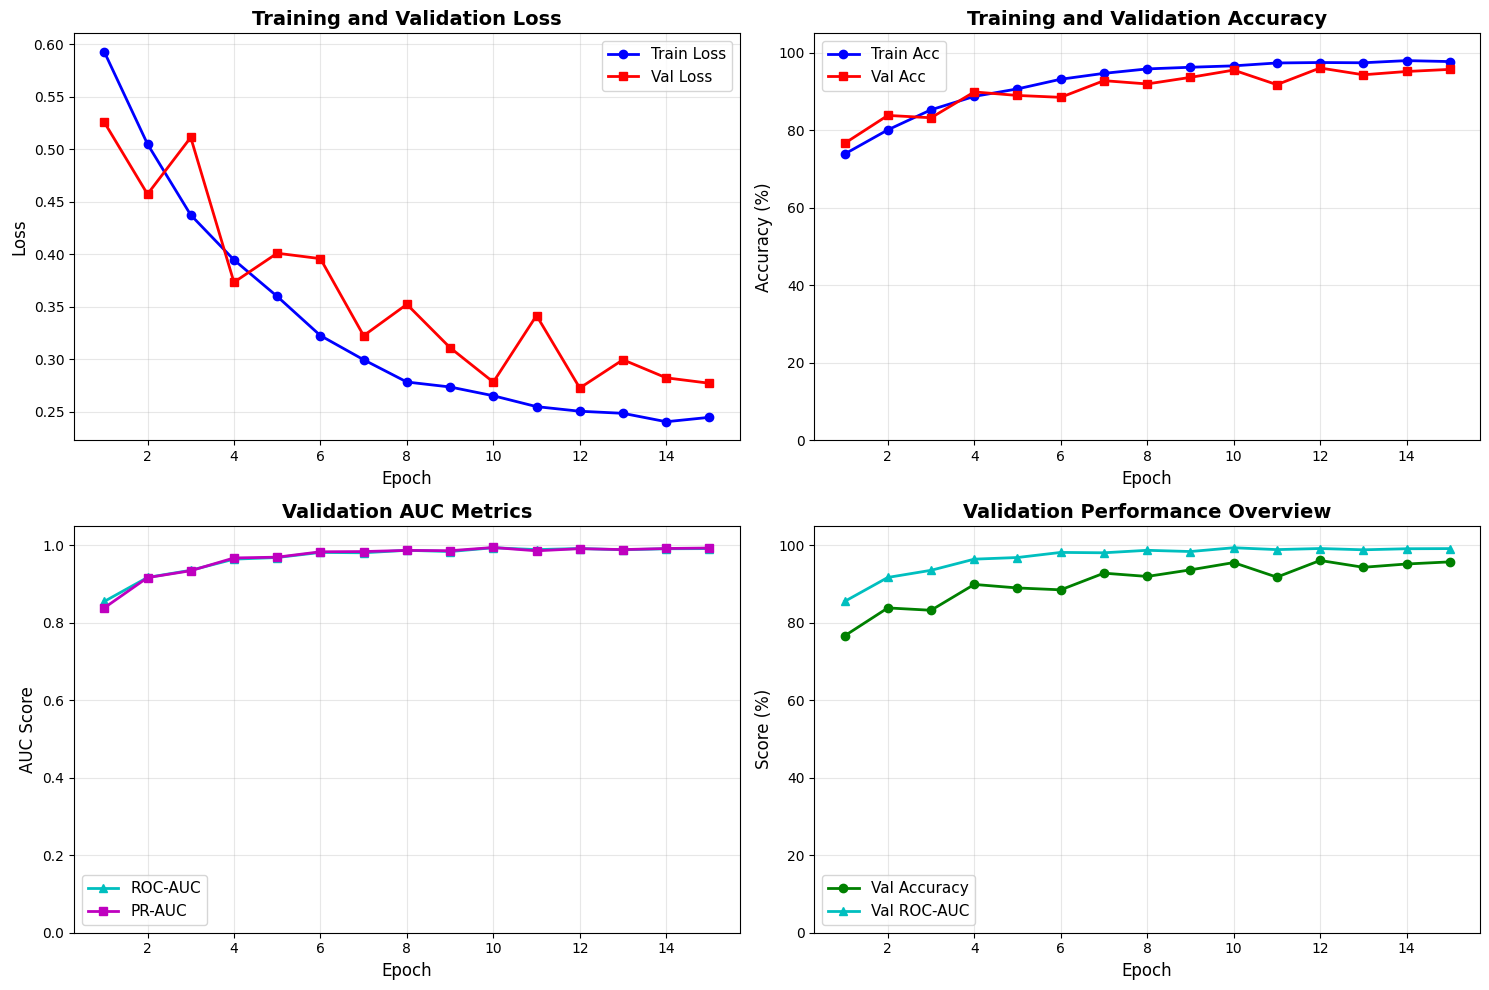

Training history plots saved.


In [8]:
# Plot training and validation metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Get actual number of epochs trained
epochs_trained = len(history['train_loss'])
epochs_range = range(1, epochs_trained + 1)

# Loss curves
axes[0, 0].plot(epochs_range, history['train_loss'], 'b-', label='Train Loss', marker='o', linewidth=2)
axes[0, 0].plot(epochs_range, history['val_loss'], 'r-', label='Val Loss', marker='s', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=12)
axes[0, 0].set_ylabel('Loss', fontsize=12)
axes[0, 0].set_title('Training and Validation Loss', fontsize=14, fontweight='bold')
axes[0, 0].legend(fontsize=11)
axes[0, 0].grid(True, alpha=0.3)

# Accuracy curves
axes[0, 1].plot(epochs_range, history['train_acc'], 'b-', label='Train Acc', marker='o', linewidth=2)
axes[0, 1].plot(epochs_range, [acc*100 for acc in history['val_accuracy']], 'r-', label='Val Acc', marker='s', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=12)
axes[0, 1].set_ylabel('Accuracy (%)', fontsize=12)
axes[0, 1].set_title('Training and Validation Accuracy', fontsize=14, fontweight='bold')
axes[0, 1].legend(fontsize=11)
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_ylim([0, 105])

# AUC metrics
axes[1, 0].plot(epochs_range, history['val_roc_auc'], 'c-', label='ROC-AUC', marker='^', linewidth=2)
axes[1, 0].plot(epochs_range, history['val_pr_auc'], 'm-', label='PR-AUC', marker='s', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=12)
axes[1, 0].set_ylabel('AUC Score', fontsize=12)
axes[1, 0].set_title('Validation AUC Metrics', fontsize=14, fontweight='bold')
axes[1, 0].legend(fontsize=11)
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_ylim([0, 1.05])

# Combined validation metrics
axes[1, 1].plot(epochs_range, [acc*100 for acc in history['val_accuracy']], 'g-', label='Val Accuracy', marker='o', linewidth=2)
axes[1, 1].plot(epochs_range, [auc*100 for auc in history['val_roc_auc']], 'c-', label='Val ROC-AUC', marker='^', linewidth=2)
axes[1, 1].set_xlabel('Epoch', fontsize=12)
axes[1, 1].set_ylabel('Score (%)', fontsize=12)
axes[1, 1].set_title('Validation Performance Overview', fontsize=14, fontweight='bold')
axes[1, 1].legend(fontsize=11)
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_ylim([0, 105])

plt.tight_layout()
plt.savefig('../saved_models/audio_cnn_gru_training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training history plots saved.")

## 9. Load Best Model and Evaluate on Validation Set

In [9]:
# Load best model
checkpoint = torch.load(MODEL_SAVE_PATH)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1} with ROC-AUC: {checkpoint['val_auc']:.4f}")

# Evaluate on validation set
print("\nEvaluating on validation set...")
val_metrics = validate(model, val_loader, criterion, device)

print(f"\nValidation Results:")
print(f"  Loss: {val_metrics['val_loss']:.4f}")
print(f"  Accuracy: {val_metrics['accuracy']:.4f}")
print(f"  PR-AUC: {val_metrics['pr_auc']:.4f}")
print(f"  ROC-AUC: {val_metrics['roc_auc']:.4f}")

Loaded best model from epoch 10 with ROC-AUC: 0.9934

Evaluating on validation set...


C:\Users\wcliang3\AppData\Local\Temp\ipykernel_17900\346077321.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_SAVE_PATH)


Validating:   0%|          | 0/52 [00:00<?, ?it/s]


Validation Results:
  Loss: 0.2794
  Accuracy: 0.9527
  PR-AUC: 0.9931
  ROC-AUC: 0.9927


## 10. Validation ROC Curve

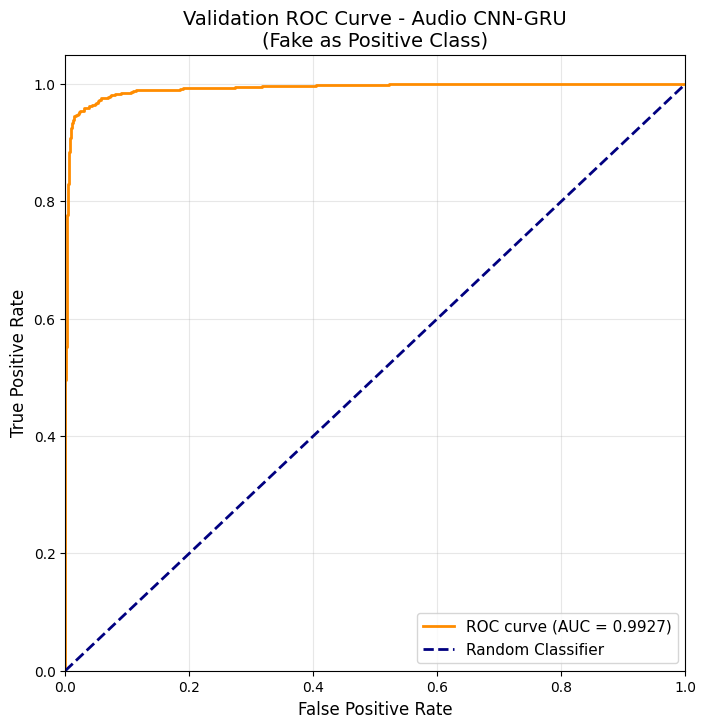

ROC curve saved.


In [10]:
# Calculate ROC curve with Fake (0) as positive class
labels_fake_positive = (np.array(val_metrics['all_labels']) == 0).astype(int)
fpr, tpr, thresholds = roc_curve(labels_fake_positive, val_metrics['all_probs'])
roc_auc_val = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (AUC = {roc_auc_val:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Validation ROC Curve - Audio CNN-GRU\n(Fake as Positive Class)', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig('../saved_models/audio_cnn_gru_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

print("ROC curve saved.")

## 11. Test Set Evaluation

In [11]:
# Evaluate on test set
print("Evaluating on test set...")
test_metrics = validate(model, test_loader, criterion, device)

print(f"\nTest Results:")
print(f"  Loss: {test_metrics['val_loss']:.4f}")
print(f"  Accuracy: {test_metrics['accuracy']:.4f}")
print(f"  PR-AUC: {test_metrics['pr_auc']:.4f}")
print(f"  ROC-AUC: {test_metrics['roc_auc']:.4f}")

Evaluating on test set...


Validating:   0%|          | 0/52 [00:00<?, ?it/s]


Test Results:
  Loss: 0.2964
  Accuracy: 0.9485
  PR-AUC: 0.9887
  ROC-AUC: 0.9916


## 12. Summary and Model Information

In [12]:
# Create summary dataframe
summary_data = {
    'Metric': ['Loss', 'Accuracy', 'PR-AUC', 'ROC-AUC'],
    'Validation': [
        f"{val_metrics['val_loss']:.4f}",
        f"{val_metrics['accuracy']:.4f}",
        f"{val_metrics['pr_auc']:.4f}",
        f"{val_metrics['roc_auc']:.4f}"
    ],
    'Test': [
        f"{test_metrics['val_loss']:.4f}",
        f"{test_metrics['accuracy']:.4f}",
        f"{test_metrics['pr_auc']:.4f}",
        f"{test_metrics['roc_auc']:.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print("\n" + "="*60)
print("FINAL MODEL PERFORMANCE SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))
print("="*60)

print(f"\nModel Architecture: AudioCNN_GRU")
print(f"Total Parameters: {total_params:,}")
print(f"Training Epochs: {NUM_EPOCHS}")
print(f"Best Model Saved: {MODEL_SAVE_PATH}")
print(f"\nPrimary Metric (ROC-AUC):")
print(f"  Validation: {val_metrics['roc_auc']:.4f}")
print(f"  Test: {test_metrics['roc_auc']:.4f}")


FINAL MODEL PERFORMANCE SUMMARY
  Metric Validation   Test
    Loss     0.2794 0.2964
Accuracy     0.9527 0.9485
  PR-AUC     0.9931 0.9887
 ROC-AUC     0.9927 0.9916

Model Architecture: AudioCNN_GRU
Total Parameters: 25,036,036
Training Epochs: 30
Best Model Saved: ../saved_models/best_audio_cnn_gru.pth

Primary Metric (ROC-AUC):
  Validation: 0.9927
  Test: 0.9916


## 13. Sample Prediction Visualization

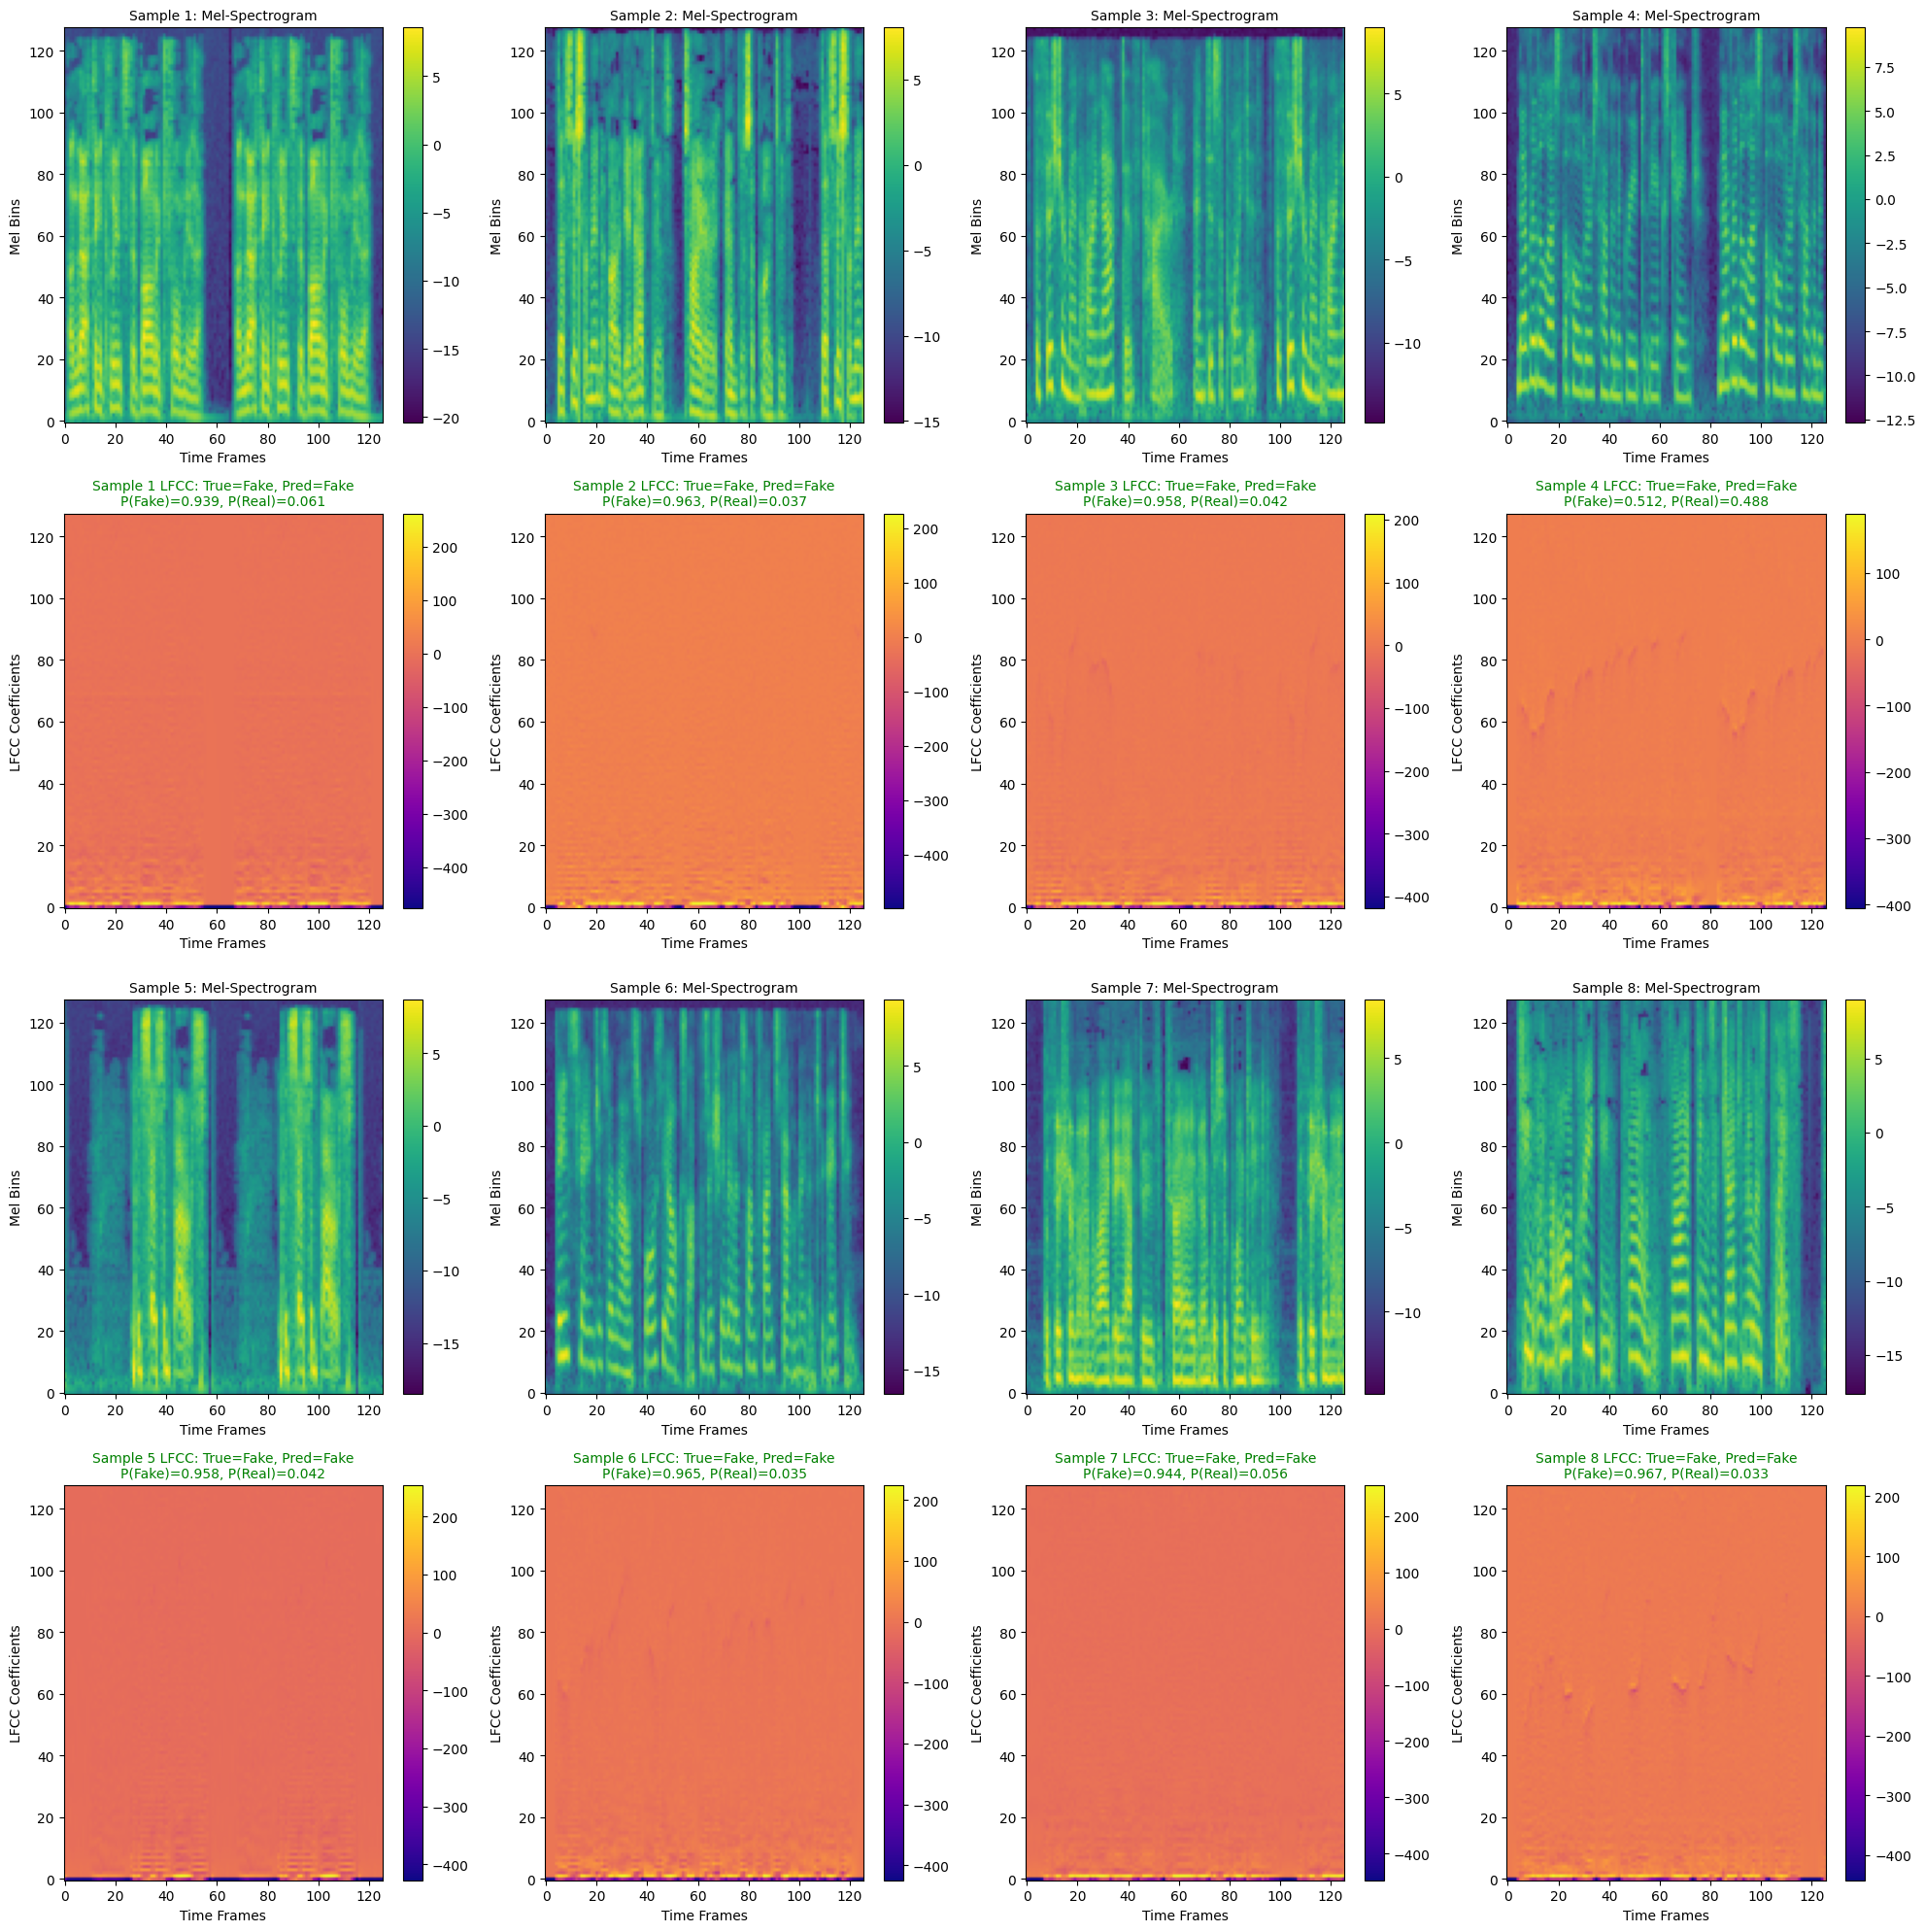


Visualized 8 test samples with dual-stream features.
  Correct predictions: 8/8


In [13]:
# Get a batch from test set
test_iter = iter(test_loader)
# UPDATED: Unpack three items (mels, lfccs, labels)
mels, lfccs, labels = next(test_iter)

# Move to device and get predictions
mels_gpu = mels.to(device)
lfccs_gpu = lfccs.to(device)
with torch.no_grad():
    # UPDATED: Forward pass with dual inputs
    logits = model(mels_gpu, lfccs_gpu)
    probs = torch.softmax(logits, dim=1).cpu().numpy()
    predictions = torch.argmax(logits, dim=1).cpu().numpy()

# Features are already extracted by the dataset
log_mels = mels.cpu()
lfccs_cpu = lfccs.cpu()

# Visualize first 8 samples showing both Mel-Spectrograms and LFCCs
fig, axes = plt.subplots(4, 4, figsize=(20, 20))

label_names = {0: 'Fake', 1: 'Real'}

for i in range(min(8, len(mels))):
    # Get log-mel spectrogram and LFCC
    log_mel = log_mels[i, 0].numpy()  # (128, TimeFrames)
    lfcc = lfccs_cpu[i, 0].numpy()    # (128, TimeFrames)
    
    # Plot Mel-Spectrogram (top row for each sample)
    ax_mel = axes[i // 4 * 2, i % 4]
    im_mel = ax_mel.imshow(log_mel, aspect='auto', origin='lower', cmap='viridis')
    ax_mel.set_xlabel('Time Frames')
    ax_mel.set_ylabel('Mel Bins')
    ax_mel.set_title(f'Sample {i+1}: Mel-Spectrogram', fontsize=10)
    plt.colorbar(im_mel, ax=ax_mel)
    
    # Plot LFCC (bottom row for each sample)
    ax_lfcc = axes[i // 4 * 2 + 1, i % 4]
    im_lfcc = ax_lfcc.imshow(lfcc, aspect='auto', origin='lower', cmap='plasma')
    ax_lfcc.set_xlabel('Time Frames')
    ax_lfcc.set_ylabel('LFCC Coefficients')
    
    # Title with prediction info (only on LFCC plot to avoid duplication)
    true_label = label_names[labels[i].item()]
    pred_label = label_names[predictions[i]]
    fake_prob = probs[i, 0]
    real_prob = probs[i, 1]
    
    color = 'green' if predictions[i] == labels[i].item() else 'red'
    ax_lfcc.set_title(
        f'Sample {i+1} LFCC: True={true_label}, Pred={pred_label}\nP(Fake)={fake_prob:.3f}, P(Real)={real_prob:.3f}',
        fontsize=10, color=color
    )
    plt.colorbar(im_lfcc, ax=ax_lfcc)

plt.tight_layout()
plt.savefig('../saved_models/audio_dual_stream_sample_predictions.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"\nVisualized {min(8, len(mels))} test samples with dual-stream features.")
print(f"  Correct predictions: {sum(predictions[:8] == labels[:8].cpu().numpy())}/{min(8, len(mels))}")

## Notebook Complete

This notebook has successfully:
1. Created a custom AudioDataset with proper preprocessing (resampling, mono conversion, standardization, wrap-around padding)
2. Implemented Log-Mel Spectrogram feature extraction
3. Built an AudioCNN_GRU model with CNN feature extraction and GRU sequence modeling
4. Trained the model for 15 epochs with ROC-AUC as the primary metric
5. Saved the best model based on Validation ROC-AUC
6. Visualized training history and ROC curves
7. Evaluated on test set with comprehensive metrics